### Analytical Forward Model 
#### with inital ensemble setup based on known values
##### combination of Sisson/Brooks-Corey analytical solution and forward model process for TDEM response

Imports

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import itertools
from simpeg import maps
from simpeg.electromagnetics import time_domain as tdem
from pathlib import Path

User inputs

In [10]:
### Set run mode of ensemble
run_mode = "texture_excel" ### options: known_soils, parameter_range, texture_excel

### set soil type parameter options for "truth" forward model
truth_soil_type = "custom"  ### options: custom, sand, loamy sand, sandy loam, loam, silt, silt loam, clay


 Desired scenario to plot must be selected in section 5, without explitic selection the next iteration will be use

In [11]:
""" theta_scenario_to_plot = next(iter(theta_results))                 ### = eplicit scenario or exsiting soil type"""    

' theta_scenario_to_plot = next(iter(theta_results))                 ### = eplicit scenario or exsiting soil type'

### 1. Define variables
##### 1.1 Soil Column and Timestamps

In [12]:
z = np.linspace(1, 2000, 300)  # cm, positive downward (20m soil column)
times = [1, 4, 12, 24, 48]   # hr

#### 1.2 ROSETTA/vG style soil parameter library

In [13]:
### Custom option for "Truth" ensemble 
custom_vg_params = {
    "custom": {
    "theta_r": 0.05,
    "theta_s": 0.4,
    "alpha": 0.1,
    "n": 2.0,
    "Ks": 10.0,
    "l": 0.5
}}
### OR preset values for sand, loamy sand, sandy loam, loam, silt, silt loam, clay

known_soils = {
    "sand": {
        "theta_r": 0.045,
        "theta_s": 0.43,
        "alpha": 0.145,
        "vg_n": 2.68,
        "Ks": 29.7,
    },
    "loamy_sand": {
        "theta_r": 0.057,
        "theta_s": 0.41,
        "alpha": 0.124,
        "vg_n": 2.28,
        "Ks": 14.6,
    },
    "sandy_loam": {
        "theta_r": 0.065,
        "theta_s": 0.41,
        "alpha": 0.075,
        "vg_n": 1.89,
        "Ks": 4.42,
    },
    "loam": {
        "theta_r": 0.078,
        "theta_s": 0.43,
        "alpha": 0.036,
        "vg_n": 1.56,
        "Ks": 1.04,
    },
    "silt": {
        "theta_r": 0.085,
        "theta_s": 0.45,
        "alpha": 0.025,
        "vg_n": 1.35,
        "Ks": 0.52,
    },
    "silty_loam": {
        "theta_r": 0.09,
        "theta_s": 0.46,
        "alpha": 0.02,
        "vg_n": 1.25,
        "Ks": 0.35,
    }, 
    "clay": {
        "theta_r": 0.1,
        "theta_s": 0.47,
        "alpha": 0.015,
        "vg_n": 1.15,
        "Ks": 0.2,
    }      
}

## 2. Analytical Solution
### 2.1 Conversion Functions

In [14]:
def vg_m(vg_n):
    """
    van Genuchten m parameter.
    """
    return 1 - (1 / vg_n)

def kr_van_genuchten_mualem(Se, vg_n, l=0.5):
    """
    van Genuchten-Mualem relative hydraulic conductivity.

    Se : effective saturation, between 0 and 1
    vg_n : van Genuchten n
    l : pore-connectivity/tortuosity parameter, commonly 0.5
    """
    Se = np.asarray(Se, dtype=float)
    Se = np.clip(Se, 1e-8, 1.0)

    m = vg_m(vg_n)

    Kr = Se**l * (1 - (1 - Se**(1 / m))**m)**2

    return Kr

### 2.2 Fitted Brooks-Corey Exponent for Each Soil Type

In [15]:
def fit_n_sisson_to_vg_mualem(vg_n, Se_min=0.1, Se_max=0.95, l=0.5):
    """
    Fit the Sisson/Brooks-Corey exponent n_sisson so that
    Kr = Se^(1/n_sisson) approximates the van Genuchten-Mualem curve.
    """

    Se = np.linspace(Se_min, Se_max, 300)
    Kr_vg = kr_van_genuchten_mualem(Se, vg_n=vg_n, l=l)

    # Avoid log of zero
    valid = (Kr_vg > 0) & (Se > 0)

    x = np.log(Se[valid])
    y = np.log(Kr_vg[valid])

    # Force fit through origin because log(Kr) = slope * log(Se)
    slope = np.sum(x * y) / np.sum(x * x)

    n_fit = 1 / slope

    return n_fit

In [16]:
for soil_name, item in known_soils.items():
    known_soils[soil_name]["bc_n_fitted"] = fit_n_sisson_to_vg_mualem(
        known_soils[soil_name]["vg_n"],
        Se_min=0.1,
        Se_max=0.95,
        l=0.5
    )

### 3. Analytical Solution Sisson/Brooks-Corey 

In [17]:
def theta_brooks_corey_sisson_piecewise(
        z, t, theta_r, theta_s, Ks, bc_n, q0,
        return_star_mid=False,
        debug=False):

    z = np.asarray(z, dtype=float)

    if t <= 0:
        return np.full_like(z, theta_s)

    # Transformed depth for saturated initial condition
    z_star = (Ks / q0) ** bc_n * z

    # Sisson variable: z*/t
    s_star = np.maximum(z_star / t, 1e-12)

    # Brooks-Corey derivative setup
    A = Ks / (bc_n * (theta_s - theta_r))
    exponent = 1 / ((1 / bc_n) - 1)

    # Middle transformed solution
    theta_star_mid = theta_r + (theta_s - theta_r) * (s_star / A) ** exponent

    if debug:
        print("bc_n =", bc_n)
        print("Ks =", Ks)
        print("q0 =", q0)
        print("A =", A)
        print("exponent =", exponent)
        print("z_star min =", z_star.min())
        print("z_star max =", z_star.max())
        print("s_star min =", s_star.min())
        print("s_star max =", s_star.max())
        print("theta_star_mid min =", theta_star_mid.min())
        print("theta_star_mid max =", theta_star_mid.max())

    if return_star_mid:
        return theta_star_mid

    # Piecewise solution based on Sisson Eq. 15

    theta_star = np.clip(theta_star_mid, theta_r, theta_s)

    return theta_star

### 4. Ensemble
### 4.1 Setup "Truth" Model 

#### Choose parameters for "Truth" based on user input
#### Custom values OR sand, loamy sand, sandy loam, loam, silt, silt loam, clay

In [18]:
def truth_vg_params(soil_type):
    truth_soil_type = soil_type.lower().strip()
    if truth_soil_type in known_soils:
        return known_soils[truth_soil_type]
    elif truth_soil_type == "custom":
        return custom_vg_params["custom"]
    else:
        print(f"Warning: Unrecognized soil type '{soil_type}'. Defaulting to 'loam' parameters.")
        return known_soils["loam"]


truth_vg_params = truth_vg_params(
    soil_type=truth_soil_type,
    )

print(truth_vg_params)

{'theta_r': 0.05, 'theta_s': 0.4, 'alpha': 0.1, 'n': 2.0, 'Ks': 10.0, 'l': 0.5}


### 4.2 Ensemble- Process a range of parameters
##### Parameter ranges based off of exsisting known soil types [Look to edit later im not sure this is the best approach]

In [19]:
from pathlib import Path
import pandas as pd

texture_excel_path = Path("C:/Users/natal/OneDrive/Desktop/26' HYDROGEO/Project [THESIS]/soils_texture_data_20191028.xlsx")

print("File exists:", texture_excel_path.exists())

xl = pd.ExcelFile(texture_excel_path)
print("Sheet names:", xl.sheet_names)

texture_df = pd.read_excel(texture_excel_path, sheet_name="soil texture data")

print(texture_df.head())
print(texture_df.columns)
print(texture_df.shape)

File exists: True
Sheet names: ['soil texture data']
   sand  silt  clay USDA Class     thr     ths  Alfa (1/cm)       n  \
0     0     0   100       clay  0.1095  0.4968       0.0159  1.1548   
1     0     2    98       clay  0.1087  0.5015       0.0165  1.1529   
2     0     4    96       clay  0.1081  0.5058       0.0172  1.1520   
3     0     6    94       clay  0.1077  0.5096       0.0178  1.1525   
4     0     8    92       clay  0.1074  0.5130       0.0184  1.1541   

   Ks (cm/day)  
0        18.49  
1        18.23  
2        17.97  
3        17.88  
4        17.80  
Index(['sand', 'silt', 'clay', 'USDA Class', 'thr', 'ths', 'Alfa (1/cm)', 'n',
       'Ks (cm/day)'],
      dtype='object')
(1326, 9)


In [20]:
from pathlib import Path

texture_excel_path = Path("C:/Users/natal/OneDrive/Desktop/26' HYDROGEO/Project [THESIS]/soils_texture_data_20191028.xlsx")

texture_df = pd.read_excel(texture_excel_path, sheet_name="soil texture data")

texture_step = 10  # options: 5 or 10

texture_df_subset = texture_df[
    (texture_df["sand"] % texture_step == 0) &
    (texture_df["silt"] % texture_step == 0) &
    (texture_df["clay"] % texture_step == 0)
].copy()

print(f"Using {len(texture_df_subset)} texture cases")

texture_excel_scenarios = {}

for row_id, row in texture_df_subset.iterrows():

    scenario_name = (
        f"texture_{row_id:04d}_"
        f"sand{int(row['sand']):03d}_"
        f"silt{int(row['silt']):03d}_"
        f"clay{int(row['clay']):03d}"
    )

    vg_n = row["n"]
    Ks_cm_hr = row["Ks (cm/day)"] / 24

    texture_excel_scenarios[scenario_name] = {
        "base_soil": row["USDA Class"],
        "sand": row["sand"],
        "silt": row["silt"],
        "clay": row["clay"],
        "USDA_class": row["USDA Class"],
        "theta_r": row["thr"],
        "theta_s": row["ths"],
        "alpha": row["Alfa (1/cm)"],
        "vg_n": vg_n,
        "Ks": Ks_cm_hr,
        "bc_n": fit_n_sisson_to_vg_mualem(vg_n),
        "q0": Ks_cm_hr
    }

print(f"Built {len(texture_excel_scenarios)} texture scenarios")

Using 66 texture cases
Built 66 texture scenarios


In [22]:
if run_mode == "known_soils":

    scenarios_to_run = {
        soil_name: {
            "base_soil": soil_name,
            "theta_r": soil["theta_r"],
            "theta_s": soil["theta_s"],
            "vg_n": soil["vg_n"],
            "Ks": soil["Ks"],
            "bc_n": soil["bc_n_fitted"],
            "q0": soil["Ks"]
        }
        for soil_name, soil in known_soils.items()
    }

elif run_mode == "parameter_range":

    scenarios_to_run = parameter_range_scenarios.copy()

elif run_mode == "texture_excel":

    scenarios_to_run = texture_excel_scenarios.copy()

else:
    raise ValueError(
        "run_mode must be 'known_soils', 'parameter_range', or 'texture_excel'"
    )

### 4.3 Build ensemble
#### Loop through each exsisting scenario
#### Edit the desired fixed and changing parameters ***

In [23]:
theta_results = {}
results = []

for scenario_name, params in scenarios_to_run.items():

    print(
        f"Running {scenario_name}: "
        f"Ks={params['Ks']:.4f}, bc_n={params['bc_n']:.4f}"
    )

    theta_results[scenario_name] = {}

    for t in times:
        theta = theta_brooks_corey_sisson_piecewise(
            z=z,
            t=t,
            theta_r=params["theta_r"],
            theta_s=params["theta_s"],
            Ks=params["Ks"],
            bc_n=params["bc_n"],
            q0=params["q0"],
            debug=False
        )

        theta_results[scenario_name][t] = theta

    results.append({
    "scenario": scenario_name,
    "base_soil": params.get("base_soil", np.nan),
    "USDA_class": params.get("USDA_class", params.get("base_soil", np.nan)),
    "sand": params.get("sand", np.nan),
    "silt": params.get("silt", np.nan),
    "clay": params.get("clay", np.nan),
    "theta_r": params["theta_r"],
    "theta_s": params["theta_s"],
    "alpha": params.get("alpha", np.nan),
    "vg_n": params.get("vg_n", np.nan),
    "bc_n": params["bc_n"],
    "Ks": params["Ks"],
    "q0": params["q0"]
})
results_df = pd.DataFrame(results)
results_df.to_csv("analytical_ensemble_summary.csv", index=False)

Running texture_0000_sand000_silt000_clay100: Ks=0.7704, bc_n=0.0534
Running texture_0005_sand000_silt010_clay090: Ks=0.7379, bc_n=0.0540
Running texture_0010_sand000_silt020_clay080: Ks=0.7129, bc_n=0.0600
Running texture_0015_sand000_silt030_clay070: Ks=0.8425, bc_n=0.0688
Running texture_0020_sand000_silt040_clay060: Ks=1.0654, bc_n=0.0805
Running texture_0025_sand000_silt050_clay050: Ks=0.6083, bc_n=0.0955
Running texture_0030_sand000_silt060_clay040: Ks=0.4321, bc_n=0.1117
Running texture_0035_sand000_silt070_clay030: Ks=0.3421, bc_n=0.1248
Running texture_0040_sand000_silt080_clay020: Ks=0.3779, bc_n=0.1336
Running texture_0045_sand000_silt090_clay010: Ks=0.7129, bc_n=0.1382
Running texture_0050_sand000_silt100_clay000: Ks=1.5842, bc_n=0.1376
Running texture_0245_sand010_silt000_clay090: Ks=0.7200, bc_n=0.0495
Running texture_0250_sand010_silt010_clay080: Ks=0.7054, bc_n=0.0538
Running texture_0255_sand010_silt020_clay070: Ks=0.7525, bc_n=0.0624
Running texture_0260_sand010_silt0

### 5. Plot water content vs Depth over time

### 5.1 reusable water content plotting function

In [24]:
def plot_theta_profiles(theta_results, scenario_name, z):
    """Plot water-content profiles through drainage time."""

    plt.figure(figsize=(6, 7))

    for t, theta_profile in theta_results[scenario_name].items():

        plt.plot(
            theta_profile,
            z,
            label=f"{t} hr"
        )

    plt.gca().invert_yaxis()
    plt.xlabel("Water content, theta")
    plt.ylabel("Depth [cm]")
    plt.title(f"Analytical drainage: {scenario_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

### Assign a specific scenario to plot, or allow the next iteration 

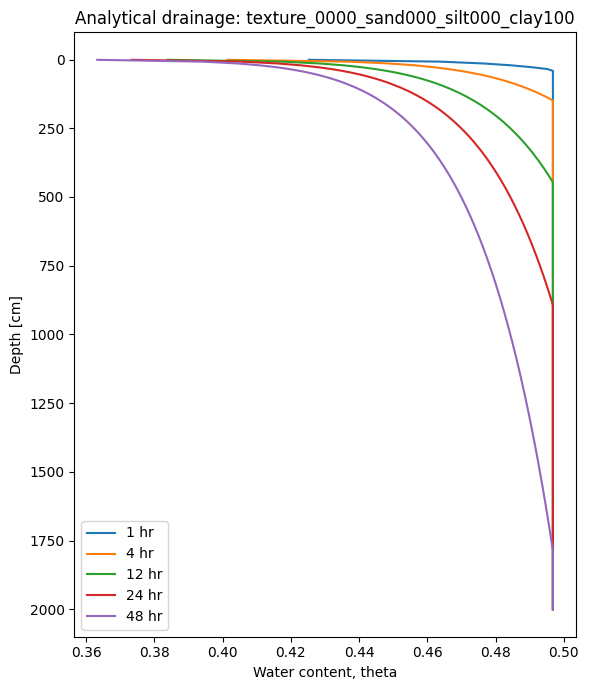

In [25]:
theta_scenario_to_plot = next(iter(theta_results))   ### = eplicit scenario or exsiting soil type 

plot_theta_profiles(
    theta_results=theta_results,
    scenario_name=theta_scenario_to_plot,
    z=z
)

### 6. Use Archies Law to convert water content to electrical conductivity. 

In [26]:
def theta_to_conductivity(theta, sigma_w, m_archie):
    """
    Convert volumetric water content to bulk electrical
    conductivity using simplified Archie's law.
    """
    sigma_bulk = sigma_w * theta**m_archie

    return sigma_bulk


# Archie parameters used for all scenarios
sigma_w = 0.1       # Water conductivity [S/m] - adjust as needed
m_archie = 1.5      # Cementation exponent - adjust as needed


# Convert every analytical theta profile to conductivity
sigma_matrices = {}

for scenario_name, time_dict in theta_results.items():

    conductivity_profiles = {}

    for t, theta_profile in time_dict.items():

        sigma_profile = theta_to_conductivity(
            theta=theta_profile,
            sigma_w=sigma_w,
            m_archie=m_archie
        )

        conductivity_profiles[t] = sigma_profile

    sigma_matrix = pd.DataFrame(
        conductivity_profiles,
        index=z
    )

    sigma_matrix.index.name = "depth_cm"

    sigma_matrices[scenario_name] = sigma_matrix

In [27]:
first_scenario = next(iter(sigma_matrices))

print("Displayed scenario:", first_scenario)
display(sigma_matrices[first_scenario].head())

Displayed scenario: texture_0000_sand000_silt000_clay100


,1,4,12,24,48
depth_cm,,,,,
1.000000,0.027732,0.025439,0.023788,0.022816,0.021894
7.685619,0.031586,0.028900,0.026968,0.025831,0.024753
14.371237,0.032896,0.030077,0.028049,0.026855,0.025724
21.056856,0.033729,0.030824,0.028734,0.027505,0.026340
27.742475,0.034345,0.031377,0.029242,0.027986,0.026796


### 7. SimPEG Forward Model 
#### 7.1 Layered model at 1 time
is this description still accurate??
extract one ec profile at one time step and determine expected TEM response, create a 1D layered TDEM forward model using SimPEG tutorial

In [28]:
# SimPEG TEM forward model from the electrical conductivity matrix

def build_tem_simulation(
    layer_thicknesses_m,
    loop_side_length_m=20.0,
    height_m=0.0,
    tem_times=None
):
    """Build one layered TDEM simulation for all ensemble profiles."""

    if tem_times is None:
        tem_times = np.logspace(-7, -2, 61)

    layer_thicknesses_m = np.asarray(
        layer_thicknesses_m,
        dtype=float
    )

    n_layers = len(layer_thicknesses_m) + 1

    receiver = tdem.receivers.PointMagneticFluxDensity(   ### OR receiver = tdem.receivers.PointMagneticFluxTimeDerivative(
        locations=np.array([[0.0, 0.0, height_m]]),
        times=tem_times,
        orientation="z"
    )

    # Equivalent-area circular loop for a 20 m x 20 m square loop
    loop_area = loop_side_length_m**2
    loop_radius = np.sqrt(loop_area / np.pi)

    source = tdem.sources.CircularLoop(
        receiver_list=[receiver],
        location=np.array([0.0, 0.0, height_m]),
        radius=loop_radius,
        orientation="z",
        waveform=tdem.sources.StepOffWaveform()
    )

    survey = tdem.Survey([source])

    conductivity_map = maps.IdentityMap(nP=n_layers)

    simulation = tdem.simulation_1d.Simulation1DLayered(
        survey=survey,
        sigmaMap=conductivity_map,
        thicknesses=layer_thicknesses_m
    )

    return simulation, tem_times

### 7.2 Layered model at all times

In [29]:
# Run TEM forward model for every timestep

# All analytical scenarios use the same depth grid
first_sigma_matrix = next(iter(sigma_matrices.values()))

depth_m = first_sigma_matrix.index.to_numpy() / 100.0
layer_thicknesses_m = np.diff(depth_m)

tem_simulation, tem_times = build_tem_simulation(
    layer_thicknesses_m=layer_thicknesses_m,
    loop_side_length_m=20.0,
    height_m=0.0
)

tem_results = {}

for scenario_name, sigma_matrix in sigma_matrices.items():

    tem_results[scenario_name] = {}

    for drainage_time in sigma_matrix.columns:

        conductivity_profile = (
            sigma_matrix[drainage_time].to_numpy(dtype=float)
        )

        response = tem_simulation.dpred(conductivity_profile)

        tem_results[scenario_name][drainage_time] = response

In [30]:
tem_response_matrices = {}

for scenario_name, time_dict in tem_results.items():

    response_matrix = pd.DataFrame(
        time_dict,
        index=tem_times
    )

    response_matrix.index.name = "TEM_time_s"

    tem_response_matrices[scenario_name] = response_matrix

### 7.3 Plot
#### response shown as TEM response over time as that is how the HYDRUS simulations have been done. Can be adjusted to give a singular response profile if desired

In [31]:
def plot_tem_response(
    tem_response_matrices,
    scenario_name,
    time_min=None,
    time_max=None
):
    response_matrix = tem_response_matrices[scenario_name]

    if time_min is None:
        time_min = response_matrix.index.min()

    if time_max is None:
        time_max = response_matrix.index.max()

    time_mask = (
        (response_matrix.index >= time_min) &
        (response_matrix.index <= time_max)
    )

    if not np.any(time_mask):
        raise ValueError(
            "No TEM times fall within the selected window."
        )

    plt.figure(figsize=(8, 6))

    for drainage_time in response_matrix.columns:

        visible_response = response_matrix.loc[
            time_mask,
            drainage_time
        ]

        plt.loglog(
            visible_response.index,
            np.abs(visible_response),
            linewidth=2,
            label=f"{drainage_time} hr"
        )

    plt.xlabel("Time after transmitter shutoff [s]")
    plt.ylabel("Predicted magnetic flux density |B| [T]")
    plt.title(f"Predicted TDEM response: {scenario_name}")

    plt.grid(True, which="major", alpha=0.5)
    plt.grid(True, which="minor", alpha=0.15)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [32]:
plot_tem_response(
    tem_response_matrices=tem_response_matrices,
    scenario_name="loam",      ### edit scenario you want to see here
    time_min=1e-7,
    time_max=1e-4
)

KeyError: 'loam'

# CLUSTERING INITAL Development 6/25/26

### 8. Cluster TDEM Responses
#### Comparison of early and late TDEM responses

each soil is represented by two TDEM decay curves from earliest and latest timesteps. Compared using log10 response due to amplitudes spanning several orders of magnitude. 

In [ ]:
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist, squareform

In [ ]:
# Compare the first and last modeled drainage states.
early_drainage_time = min(times)
late_drainage_time = max(times)

# Use the same receiver-time window used in the TDEM plot above.
comparison_time_min = 1e-7
comparison_time_max = 1e-4

print(f"Early drainage profile: {early_drainage_time} hr")
print(f"Late drainage profile: {late_drainage_time} hr")

Early drainage profile: 1 hr
Late drainage profile: 48 hr


### 8.1 Overlay early/late time responses for all soils

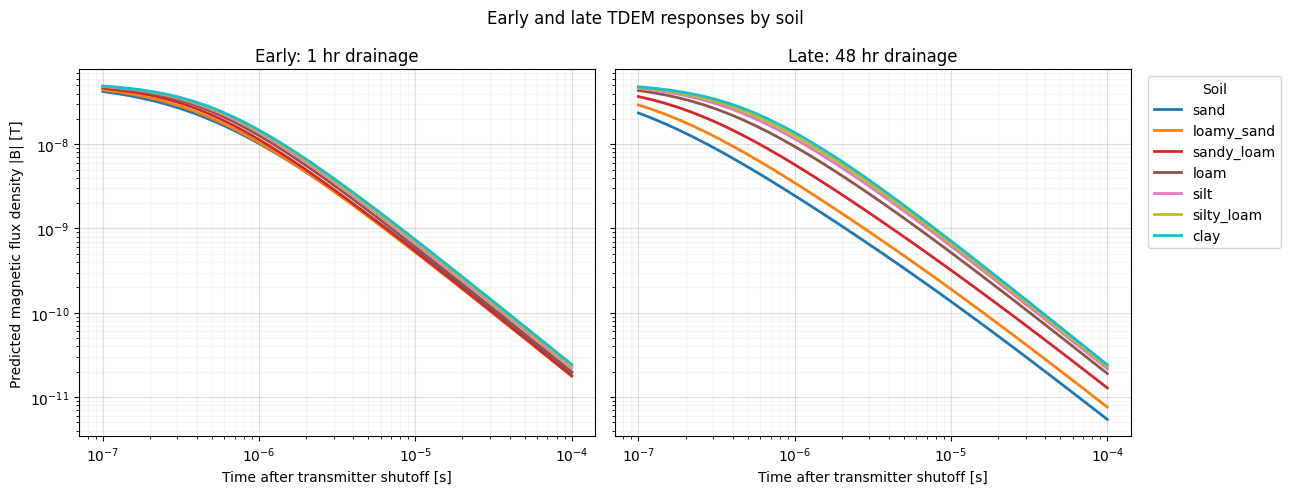

In [ ]:
def plot_early_late_responses(
    tem_response_matrices,
    early_time,
    late_time,
    time_min=None,
    time_max=None
):
    """Plot all scenarios at the selected early and late drainage times."""

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
    colors = plt.cm.tab10(np.linspace(0, 1, len(tem_response_matrices)))

    for color, (scenario_name, response_matrix) in zip(
        colors, tem_response_matrices.items()
    ):
        time_mask = np.ones(len(response_matrix), dtype=bool)

        if time_min is not None:
            time_mask &= response_matrix.index.to_numpy() >= time_min
        if time_max is not None:
            time_mask &= response_matrix.index.to_numpy() <= time_max

        visible_times = response_matrix.index.to_numpy()[time_mask]

        for axis, drainage_time, label in zip(
            axes,
            [early_time, late_time],
            ["Early", "Late"]
        ):
            response = np.abs(
                response_matrix.loc[time_mask, drainage_time].to_numpy(dtype=float)
            )
            axis.loglog(
                visible_times,
                response,
                color=color,
                linewidth=2,
                label=scenario_name
            )
            axis.set_title(f"{label}: {drainage_time} hr drainage")
            axis.set_xlabel("Time after transmitter shutoff [s]")
            axis.grid(True, which="major", alpha=0.4)
            axis.grid(True, which="minor", alpha=0.12)

    axes[0].set_ylabel("Predicted magnetic flux density |B| [T]")
    axes[1].legend(title="Soil", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle("Early and late TDEM responses by soil")
    fig.tight_layout()
    plt.show()


plot_early_late_responses(
    tem_response_matrices=tem_response_matrices,
    early_time=early_drainage_time,
    late_time=late_drainage_time,
    time_min=comparison_time_min,
    time_max=comparison_time_max
)


### 8.15 Check to see if comparison order matters

In [ ]:
#from sklearn.cluster import KMeans
#from sklearn.metrics import silhouette_score


def build_soil_vectors(order="early_late"):
    """
    Build one response vector per soil using either:
    - early_late: [early response, late response]
    - late_early: [late response, early response]
    """

    soil_names = []
    vectors = []

    for soil_name, response_matrix in tem_response_matrices.items():

        early_response = response_matrix[early_drainage_time][comparison_mask]
        late_response = response_matrix[late_drainage_time][comparison_mask]

        early_log = np.log10(np.abs(early_response))
        late_log = np.log10(np.abs(late_response))

        if order == "early_late":
            vector = np.concatenate([early_log, late_log])

        elif order == "late_early":
            vector = np.concatenate([late_log, early_log])

        else:
            raise ValueError("order must be 'early_late' or 'late_early'")

        soil_names.append(soil_name)
        vectors.append(vector)

    return soil_names, np.vstack(vectors)

In [ ]:
def build_early_late_feature_table(
    tem_response_matrices,
    early_time,
    late_time,
    time_min=None,
    time_max=None,
    response_floor=1e-30,
    order="early_late"
):
    """
    Return one log10 response vector per soil.

    order="early_late" builds:
        [early response, late response]

    order="late_early" builds:
        [late response, early response]
    """

    feature_rows = {}
    feature_columns = None

    for scenario_name, response_matrix in tem_response_matrices.items():

        time_mask = np.ones(len(response_matrix), dtype=bool)

        if time_min is not None:
            time_mask &= response_matrix.index.to_numpy() >= time_min
        if time_max is not None:
            time_mask &= response_matrix.index.to_numpy() <= time_max

        selected_tem_times = response_matrix.index.to_numpy()[time_mask]

        early_response = np.abs(
            response_matrix.loc[time_mask, early_time].to_numpy(dtype=float)
        )
        late_response = np.abs(
            response_matrix.loc[time_mask, late_time].to_numpy(dtype=float)
        )

        early_log_response = np.log10(np.maximum(early_response, response_floor))
        late_log_response = np.log10(np.maximum(late_response, response_floor))

        if order == "early_late":
            feature_vector = np.concatenate([
                early_log_response,
                late_log_response
            ])

            column_labels = (
                [f"early_{tem_time:.3e}_s" for tem_time in selected_tem_times]
                +
                [f"late_{tem_time:.3e}_s" for tem_time in selected_tem_times]
            )

        elif order == "late_early":
            feature_vector = np.concatenate([
                late_log_response,
                early_log_response
            ])

            column_labels = (
                [f"late_{tem_time:.3e}_s" for tem_time in selected_tem_times]
                +
                [f"early_{tem_time:.3e}_s" for tem_time in selected_tem_times]
            )

        else:
            raise ValueError("order must be 'early_late' or 'late_early'")

        feature_rows[scenario_name] = feature_vector

        if feature_columns is None:
            feature_columns = column_labels

    return pd.DataFrame.from_dict(
        feature_rows,
        orient="index",
        columns=feature_columns
    )

In [ ]:

clustering_features_EL = build_early_late_feature_table(
    tem_response_matrices=tem_response_matrices,
    early_time=early_drainage_time,
    late_time=late_drainage_time,
    time_min=comparison_time_min,
    time_max=comparison_time_max,
    order="early_late"
)

clustering_features_LE = build_early_late_feature_table(
    tem_response_matrices=tem_response_matrices,
    early_time=early_drainage_time,
    late_time=late_drainage_time,
    time_min=comparison_time_min,
    time_max=comparison_time_max,
    order="late_early"
)

display(clustering_features_EL.iloc[:, :5])
#display(clustering_features_LE.iloc[:, :5])

clustering_features = clustering_features_EL  ## OR  clustering_features_LE

,early_1.000e-07_s,early_1.212e-07_s,early_1.468e-07_s,early_1.778e-07_s,early_2.154e-07_s
sand,-7.374082,-7.396248,-7.422460,-7.453286,-7.489258
loamy_sand,-7.356182,-7.376065,-7.400048,-7.428896,-7.463355
sandy_loam,-7.333931,-7.350863,-7.371780,-7.397605,-7.429286
loam,-7.319786,-7.334462,-7.352760,-7.375615,-7.404042
silt,-7.313725,-7.327140,-7.343876,-7.364820,-7.390980
silty_loam,-7.311174,-7.324038,-7.340087,-7.360179,-7.385311
clay,-7.308768,-7.321115,-7.336516,-7.355804,-7.379959


### 8.3 Calculate similarity

the log-RMSE across all selected reciever times and both drainage timesteps. A smaller distance indicates less distinguishable change between the TDEM responses

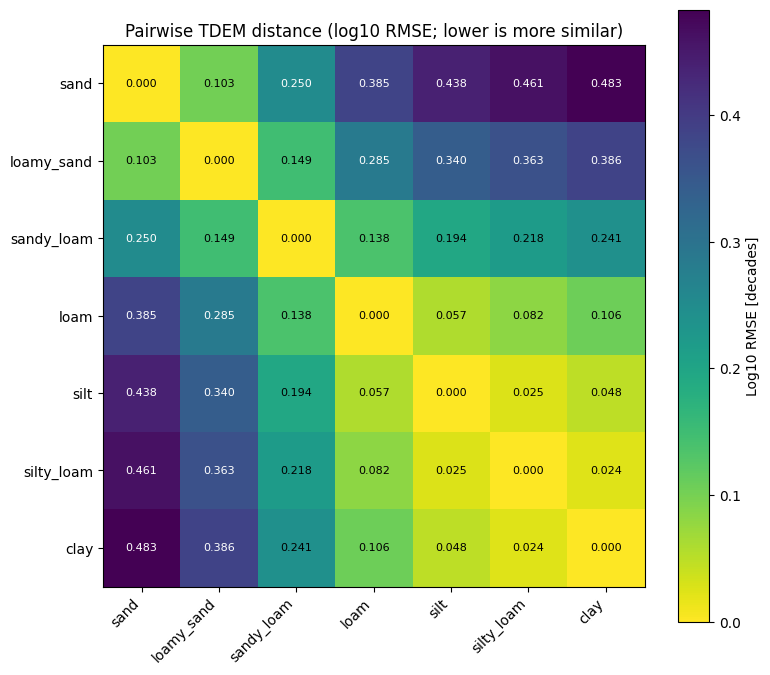

,soil_1,soil_2,log10_rmse_decades,typical_amplitude_factor
0,silty_loam,clay,0.023703,1.056096
1,silt,silty_loam,0.024796,1.058756
2,silt,clay,0.048498,1.118146
3,loam,silt,0.057458,1.141454
4,loam,silty_loam,0.082224,1.208437
5,sand,loamy_sand,0.102840,1.267186
6,loam,clay,0.105899,1.276143
7,sandy_loam,loam,0.137718,1.373150
8,loamy_sand,sandy_loam,0.148647,1.408143
9,sandy_loam,silt,0.193865,1.562662


In [ ]:
# Scaling by sqrt(number of features) makes Euclidean distance equal
# to RMSE in log10 response units.
rmse_scaled_features = (
    clustering_features.to_numpy(dtype=float)
    / np.sqrt(clustering_features.shape[1])
)

condensed_distances = pdist(rmse_scaled_features, metric="euclidean")
distance_matrix = pd.DataFrame(
    squareform(condensed_distances),
    index=clustering_features.index,
    columns=clustering_features.index
)

fig, ax = plt.subplots(figsize=(8, 7))
image = ax.imshow(distance_matrix, cmap="viridis_r")
ax.set_xticks(range(len(distance_matrix.columns)))
ax.set_xticklabels(distance_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(distance_matrix.index)))
ax.set_yticklabels(distance_matrix.index)

for row in range(len(distance_matrix.index)):
    for column in range(len(distance_matrix.columns)):
        ax.text(
            column,
            row,
            f"{distance_matrix.iloc[row, column]:.3f}",
            ha="center",
            va="center",
            fontsize=8,
            color=(
                "white"
                if distance_matrix.iloc[row, column] > distance_matrix.to_numpy().max() / 2
                else "black"
            )
        )

ax.set_title("Pairwise TDEM distance (log10 RMSE; lower is more similar)")
fig.colorbar(image, ax=ax, label="Log10 RMSE [decades]")
fig.tight_layout()
plt.show()

# Rank the unique soil pairs from most to least similar.
pairwise_rows = []
soil_names = list(distance_matrix.index)

for first_index, first_soil in enumerate(soil_names):
    for second_soil in soil_names[first_index + 1:]:
        log_rmse = distance_matrix.loc[first_soil, second_soil]
        pairwise_rows.append({
            "soil_1": first_soil,
            "soil_2": second_soil,
            "log10_rmse_decades": log_rmse,
            "typical_amplitude_factor": 10**log_rmse
        })

closest_soil_pairs = (
    pd.DataFrame(pairwise_rows)
    .sort_values("log10_rmse_decades")
    .reset_index(drop=True)
)

display(closest_soil_pairs)


### 8.4 K-Means Clustering
#### Looks at soil vectors and determines which have similar early/later response patterns. 
K-means does not know anything about sand, loam, or clay. It only sees numerical response vectors and groups the most similar vectors together.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k = 4

X_EL = clustering_features_EL.to_numpy(dtype=float)
X_LE = clustering_features_LE.to_numpy(dtype=float)

kmeans_EL = KMeans(n_clusters=k, random_state=0, n_init=20)
kmeans_LE = KMeans(n_clusters=k, random_state=0, n_init=20)

labels_EL = kmeans_EL.fit_predict(X_EL)
labels_LE = kmeans_LE.fit_predict(X_LE)

kmeans_order_comparison = pd.DataFrame({
    "soil": clustering_features_EL.index,
    "cluster_early_late": labels_EL,
    "cluster_late_early": labels_LE
})

display(kmeans_order_comparison)

print("Early-late inertia:", kmeans_EL.inertia_)
print("Late-early inertia:", kmeans_LE.inertia_)

if len(set(labels_EL)) > 1:
    print("Early-late silhouette:", silhouette_score(X_EL, labels_EL))

if len(set(labels_LE)) > 1:
    print("Late-early silhouette:", silhouette_score(X_LE, labels_LE))

c:\Users\natal\anaconda3\envs\hydro_tdem\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\natal\anaconda3\envs\hydro_tdem\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,soil,cluster_early_late,cluster_late_early
0,sand,2,2
1,loamy_sand,3,3
2,sandy_loam,0,0
3,loam,1,1
4,silt,1,1
5,silty_loam,1,1
6,clay,1,1


Early-late inertia: 0.4589058114705359
Late-early inertia: 0.4589058114705358
Early-late silhouette: 0.3907062049262704
Late-early silhouette: 0.3907062049253874


### 8.5 Hierarchial Clustering

Use calculated distances to organize soils according to similarity of early/late TDEM responses. ** At this stage, the clustering is exploratory because the responses are noise-free. Later, adding simulated or field-based uncertainty will reveal whether the same groups remain stable and therefore genuinely distinguishable.**

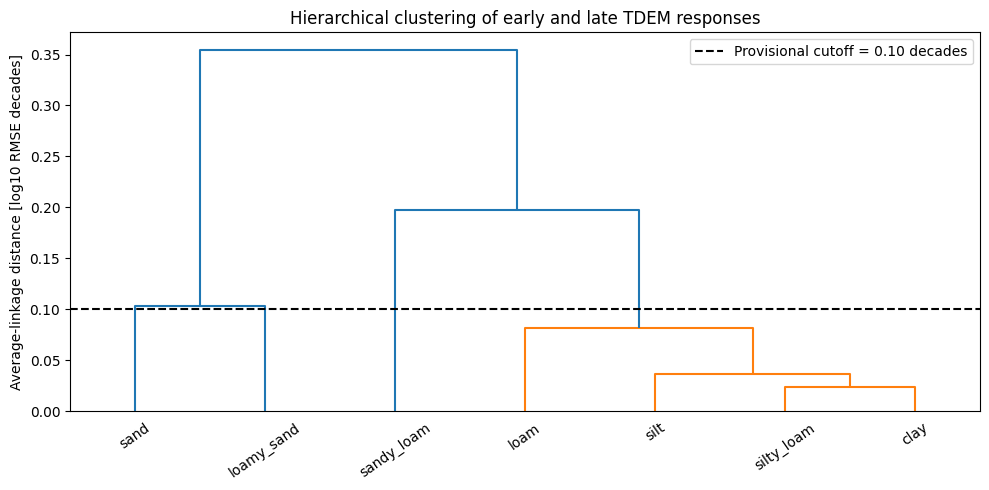

,cluster,theta_r,theta_s,vg_n,bc_n,Ks
sand,1,0.045,0.43,2.68,0.228388,29.70
loamy_sand,2,0.057,0.41,2.28,0.202836,14.60
clay,3,0.100,0.47,1.15,0.052168,0.20
silty_loam,3,0.090,0.46,1.25,0.076236,0.35
silt,3,0.085,0.45,1.35,0.096237,0.52
loam,3,0.078,0.43,1.56,0.129989,1.04
sandy_loam,4,0.065,0.41,1.89,0.169267,4.42


In [ ]:
linkage_matrix = linkage(
    rmse_scaled_features,
    method="average",
    metric="euclidean"
)

# Provisional similarity tolerance. Replace with a value justified by the
# field instrument/noise model when that information is available.
cluster_threshold_decades = 0.10

cluster_labels = fcluster(
    linkage_matrix,
    t=cluster_threshold_decades,
    criterion="distance"
)

cluster_summary = results_df.set_index("scenario").loc[
    clustering_features.index,
    ["theta_r", "theta_s", "vg_n", "bc_n", "Ks"]
].copy()
cluster_summary.insert(0, "cluster", cluster_labels)
cluster_summary = cluster_summary.sort_values(["cluster", "Ks"])

plt.figure(figsize=(10, 5))
dendrogram(
    linkage_matrix,
    labels=clustering_features.index.tolist(),
    leaf_rotation=35,
    leaf_font_size=10,
    color_threshold=cluster_threshold_decades
)
plt.axhline(
    cluster_threshold_decades,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"Provisional cutoff = {cluster_threshold_decades:.2f} decades"
)
plt.ylabel("Average-linkage distance [log10 RMSE decades]")
plt.title("Hierarchical clustering of early and late TDEM responses")
plt.legend()
plt.tight_layout()
plt.show()

display(cluster_summary)


Later... I could convert backwards to the electrical conductivity profile, then the water content profile, then......figure out the vG parameters. if that is still relevant